**Retail Price Optimisation (Demand Model + Profit Uplift**

Price optimization involves using historical data to determine the ideal price for a product or service, aiming to maximize profitability while balancing efficient pricing, profit objectives, and customer satisfaction.

**Aim**
Develop a pricing system that recommends prices which maximise profit while avoiding data leakage and over-optimistic evaluation.


**Objectives:**
1. Import Libraries: Import all necessary Python libraries
2. Download and Load Dataset
3. Initial Data Preparation: Convert the 'month_year' column to datetime objects and extract 'month' and 'year' features for seasonality.
4. Data Cleaning and Filtering: Clean the dataset by dropping rows with missing essential values, ensuring numeric types, filtering for sensible positive values, and sorting by product and time for subsequent feature engineering.
5. Feature Engineering: Create leakage-safe time-series features such as lagged quantities and prices, rolling means, and price change from the previous month, all computed per product.
6. Time-Series Data Split: Split the dataset chronologically into training, validation, and test sets.
7. Train Demand Prediction Model: Define and train a demand prediction model using a HistGradientBoostingRegressor within a scikit-learn pipeline, incorporating one-hot encoding for categorical features.
8. Evaluate Demand Model Performance: Evaluate the trained demand model's performance on the validation and test sets using Mean Absolute Error (MAE) and R² score, and compare it against a naive baseline.
9. Implement Price Optimization Strategy: Develop and apply a price optimization strategy on the test set to maximize a profit proxy by searching for optimal prices within a defined range and historical bounds.
10. Analyze Price Optimization Results: Quantify and analyze the total profit uplift and key metrics from the price optimization.
11. Visualize Optimization Results: Generate plots to visualize the the data and form conclusions.

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suddharshan/retail-price-optimization")

Using Colab cache for faster access to the 'retail-price-optimization' dataset.


In [ ]:
import os

# The 'path' variable already holds the directory where the dataset was downloaded.
# We need to find the actual CSV file within this directory.

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in the downloaded directory: {path}")

# Assuming there's only one CSV file or the relevant one is the first found.
# If there are multiple, you might need more specific logic to pick the correct one.
file_name = csv_files[0]
dataset_path = os.path.join(path, file_name)

df = pd.read_csv(dataset_path)
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


Monthly retail data covering 52 products across 9 categories with historical prices, sales volume, customer demand signals, and competitor pricing.

We need month_year as a real datetime so we can:
- sort chronologically (required for lag features)
- split train/val/test in time order (prevent future leakage)

**Profit is a proxy**: the dataset does not include unit cost. We assume a constant margin rate (default 25%).  
> Replace this with true cost when available: `profit = (price - cost) * qty`.

In [ ]:
# Convert month_year string -> datetime (invalid parses become NaT)
df["month_year"] = pd.to_datetime(df["month_year"], format="%d-%m-%Y", errors="coerce")

In [ ]:
# Create seasonality features directly from the date (safe, no leakage)
df["month"] = df["month_year"].dt.month
df["year"] = df["month_year"].dt.year

**Data Cleaning**

- Convert `month_year` to datetime for correct sorting, splitting, and seasonality features.  
- Remove invalid rows so the model trains reliably.

In [ ]:
# We drop rows missing essential fields. This prevents:
# - training failures
# - biased demand estimates from malformed rows
df = df.dropna(subset=["month_year", "unit_price", "qty"]).copy()

In [ ]:
# Ensure numeric types
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
df = df.dropna(subset=["unit_price", "qty"]).copy()

In [ ]:
# Keep only sensible values
df = df[(df.unit_price > 0) & (df.qty >= 0)].copy()

In [ ]:
# Sort by product + time (critical for lags)
df = df.sort_values(["product_id", "month_year"]).reset_index(drop=True)

In [ ]:
print("Rows:", len(df))
print("Products:", df["product_id"].nunique())
print("Months:", df["month_year"].nunique())

Rows: 676
Products: 52
Months: 20


**Leakage-safe feature engineering**

Predict demand in month *t* using only information available up to month *t-1*.

We create:
- qty_lag1, price_lag1
- rolling means based on past only: qty_roll3_mean, price_roll3_mean
- price_change_1m = current price - last month's price

Rolling features are computed **per product** (no cross-product mixing).


In [ ]:
# Lag features (per product)
df["qty_lag1"] = df.groupby("product_id")["qty"].shift(1)
df["price_lag1"] = df.groupby("product_id")["unit_price"].shift(1)

# Rolling means computed PER PRODUCT (past-only: shift(1) before rolling)
df["qty_roll3_mean"] = df.groupby("product_id")["qty"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)
df["price_roll3_mean"] = df.groupby("product_id")["unit_price"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)

# Price change vs last month (captures demand response to changes)
df["price_change_1m"] = df["unit_price"] - df["price_lag1"]

# Drop first month per product where lag features are missing
df = df.dropna(subset=["qty_lag1", "price_lag1"]).reset_index(drop=True)

df[["product_id","month_year","unit_price","qty","qty_lag1","qty_roll3_mean","price_lag1","price_roll3_mean","price_change_1m"]].head(10)


,product_id,month_year,unit_price,qty,qty_lag1,qty_roll3_mean,price_lag1,price_roll3_mean,price_change_1m
0,bed1,2017-06-01,45.950000,3,1.0,1.000000,45.950000,45.950000,0.000000
1,bed1,2017-07-01,45.950000,6,3.0,2.000000,45.950000,45.950000,0.000000
2,bed1,2017-08-01,45.950000,4,6.0,3.333333,45.950000,45.950000,0.000000
3,bed1,2017-09-01,45.950000,2,4.0,4.333333,45.950000,45.950000,0.000000
4,bed1,2017-10-01,45.950000,3,2.0,4.000000,45.950000,45.950000,0.000000
5,bed1,2017-11-01,40.531818,11,3.0,3.000000,45.950000,45.950000,-5.418182
6,bed1,2017-12-01,39.990000,6,11.0,5.333333,40.531818,44.143939,-0.541818
7,bed1,2018-01-01,39.990000,19,6.0,6.666667,39.990000,42.157273,0.000000
8,bed1,2018-02-01,39.990000,18,19.0,12.000000,39.990000,40.170606,0.000000
9,bed1,2018-03-01,39.990000,17,18.0,14.333333,39.990000,39.990000,0.000000


**Time-series split (no future leakage)**

Random splitting leaks future patterns into training and inflates results.

We simulate real deployment:
- Train on earlier months
- Validate on later months (for tuning)
- Test on the last months (final unbiased evaluation)

In [ ]:
TEST_MONTHS = 3
VAL_MONTHS = 2

months = np.sort(df["month_year"].unique())
if len(months) < (TEST_MONTHS + VAL_MONTHS + 6):
    print("Warning: few months available. Consider reducing TEST_MONTHS/VAL_MONTHS.")

test_months = months[-TEST_MONTHS:]
val_months = months[-(TEST_MONTHS + VAL_MONTHS):-TEST_MONTHS]
train_months = months[:-(TEST_MONTHS + VAL_MONTHS)]

train_df = df[df["month_year"].isin(train_months)].copy()
val_df   = df[df["month_year"].isin(val_months)].copy()
test_df  = df[df["month_year"].isin(test_months)].copy()

print("Train months:", train_df["month_year"].nunique(), "rows:", len(train_df))
print("Val months:", val_df["month_year"].nunique(), "rows:", len(val_df))
print("Test months:", test_df["month_year"].nunique(), "rows:", len(test_df))


Train months: 14 rows: 416
Val months: 2 rows: 88
Test months: 3 rows: 120


**Demand model (predict quantity)**

For price optimisation, price is the decision variable.  
So we model **demand** as a function of price + context + history.

We use:
- One-hot encoding for product/category
- Gradient boosting regressor for tabular non-linear relationships

We also compute a **naive baseline**: predict next month's demand = last month's demand.


In [ ]:
# - price is the decision variable
# - qty is what the business wants to predict (demand response)

target = "qty"

# Numeric features (we'll only keep those that exist)
numeric_features = [
    "unit_price",
    "qty_lag1", "qty_roll3_mean",
    "price_lag1", "price_roll3_mean",
    "price_change_1m",
    "customers", "weekday", "weekend", "holiday",
    "product_weight_g", "product_score",
    "comp_1", "comp_2", "comp_3",
    "fp1", "fp2", "fp3",
    "month", "year"
]
numeric_features = [c for c in numeric_features if c in df.columns]

categorical_features = []
for c in ["product_id", "product_category_name"]:
    if c in df.columns:
        categorical_features.append(c)

In [ ]:
X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target]

X_val = val_df[numeric_features + categorical_features]
y_val = val_df[target]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target]

In [ ]:
# Preprocess: one-hot categorical + pass numeric through
# sparse=False keeps things simple
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop"
)

model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_leaf_nodes=31,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

In [ ]:
pipe.fit(X_train, y_train)

# Clip predictions: demand can't be negative
val_pred = np.clip(pipe.predict(X_val), 0, None)
test_pred = np.clip(pipe.predict(X_test), 0, None)

print("Validation MAE:", mean_absolute_error(y_val, val_pred))
print("Validation R² :", r2_score(y_val, val_pred))

print("\nTest MAE:", mean_absolute_error(y_test, test_pred))
print("Test R² :", r2_score(y_test, test_pred))

Validation MAE: 9.158700910521118
Validation R² : 0.5380442594693712

Test MAE: 7.118942303527975
Test R² : -0.15749081711527757


MAE calculates the average difference between the predicted values and the actual observed values (how 'wrong' predictions are).

A lower MAE means that on average, the model's predictions are closer to the actual values. Therefore, a lower MAE indicates higher model accuracy.

In [ ]:
# Naive baseline: predict demand = last month's demand
naive_pred = test_df["qty_lag1"].values
print("\nNaive baseline MAE (qty_lag1):", mean_absolute_error(y_test, naive_pred))


Naive baseline MAE (qty_lag1): 8.333333333333334


Our model shows a positive sign by having a lower average error (Test MAE of 7.12) compared to just using last month's sales as a guess (Naive MAE of 8.33), meaning it's better than a very simple approach. However,  negative R² on the test set (-0.157), indicates that while the average error is acceptable, the model isn't effectively capturing or explaining the overall patterns and variations in demand for new, unseen data.

**Price optimisation step**

Because **unit cost is missing**, we use a **profit proxy**:

\[
\text{profit\_proxy} = (\text{margin\_rate} \times \text{price}) \times \hat{qty}
\]

We search candidate prices within ±20% of current price, and apply a **realistic constraint**:
- candidate prices are clipped to the product’s **historical min/max price** to avoid unrealistic recommendations.


In [ ]:
MARGIN_RATE = 0.25
PRICE_MIN_FACTOR = 0.80
PRICE_MAX_FACTOR = 1.20
N_PRICE_POINTS = 21

def profit_proxy(price: np.ndarray, qty: np.ndarray, margin_rate: float = 0.25) -> np.ndarray:
    return (margin_rate * price) * qty

# Historical price bounds per product (guardrail)
price_bounds = (
    df.groupby("product_id")["unit_price"]
      .agg(["min", "max"])
      .rename(columns={"min":"hist_min","max":"hist_max"})
)

# Optimise prices on the TEST set (simulating future deployment decisions)
opt_base = test_df.copy().merge(price_bounds, left_on="product_id", right_index=True, how="left")

# Candidate multipliers
multipliers = np.linspace(PRICE_MIN_FACTOR, PRICE_MAX_FACTOR, N_PRICE_POINTS)

# Base predictions and profit proxy under current price
X_base = opt_base[numeric_features + categorical_features].copy()
qty_base = np.clip(pipe.predict(X_base), 0, None)
profit_base = profit_proxy(opt_base["unit_price"].values, qty_base, margin_rate=MARGIN_RATE)

best_price = opt_base["unit_price"].values.copy()
best_profit = profit_base.copy()
best_qty = qty_base.copy()

for m in multipliers:
    X_tmp = X_base.copy()

    cand_price = opt_base["unit_price"].values * m
    # Apply historical bounds to keep recommendations realistic
    cand_price = np.clip(cand_price, opt_base["hist_min"].values, opt_base["hist_max"].values)

    X_tmp["unit_price"] = cand_price

    # Keep price-derived feature consistent
    if "price_change_1m" in X_tmp.columns:
        X_tmp["price_change_1m"] = X_tmp["unit_price"] - X_tmp["price_lag1"]

    qty_hat = np.clip(pipe.predict(X_tmp), 0, None)
    profit_hat = profit_proxy(cand_price, qty_hat, margin_rate=MARGIN_RATE)

    improve = profit_hat > best_profit
    best_profit[improve] = profit_hat[improve]
    best_price[improve] = cand_price[improve]
    best_qty[improve] = qty_hat[improve]

opt_results = opt_base[["month_year","product_id","product_category_name","unit_price"]].copy()
opt_results = opt_results.rename(columns={"unit_price":"current_price"})
opt_results["optimal_price"] = best_price

opt_results["pred_qty_current"] = qty_base
opt_results["pred_qty_optimal"] = best_qty

opt_results["profit_current"] = profit_base
opt_results["profit_optimised"] = best_profit
opt_results["profit_uplift"] = opt_results["profit_optimised"] - opt_results["profit_current"]
opt_results["profit_uplift_pct"] = np.where(
    opt_results["profit_current"] > 0,
    opt_results["profit_uplift"] / opt_results["profit_current"],
    np.nan
)

In [ ]:
total_current = opt_results["profit_current"].sum()
total_opt = opt_results["profit_optimised"].sum()
uplift = total_opt - total_current
uplift_pct = uplift / total_current if total_current > 0 else np.nan

print("Total profit proxy (baseline):", total_current)
print("Total profit proxy (optimised):", total_opt)
print("Uplift:", uplift)
print("Uplift %:", uplift_pct)

opt_results.head()


Total profit proxy (baseline): 39759.11537524666
Total profit proxy (optimised): 45680.16735938992
Uplift: 5921.051984143254
Uplift %: 0.14892313192233644


,month_year,product_id,product_category_name,current_price,optimal_price,pred_qty_current,pred_qty_optimal,profit_current,profit_optimised,profit_uplift,profit_uplift_pct
12,2018-06-01,bed1,bed_bath_table,39.990000,39.240,11.852439,17.191659,118.494764,168.650172,50.155408,0.423271
13,2018-07-01,bed1,bed_bath_table,39.990000,45.950,6.658977,6.818172,66.573119,78.323755,11.750636,0.176507
14,2018-08-01,bed1,bed_bath_table,39.240000,45.950,9.034680,9.457053,88.630212,108.637893,20.007681,0.225743
30,2018-06-01,bed2,bed_bath_table,79.900000,76.704,17.381223,21.894030,347.189927,419.839912,72.649985,0.209251
31,2018-07-01,bed2,bed_bath_table,77.933333,74.816,17.851496,20.234163,347.806654,378.459777,30.653123,0.088133


In [ ]:
# what % of recommendations hit the bounds
hit_min = (opt_results["optimal_price"] == opt_base["hist_min"]).mean()
hit_max = (opt_results["optimal_price"] == opt_base["hist_max"]).mean()
print("Pct hitting min bound:", hit_min)
print("Pct hitting max bound:", hit_max)


**Visualisations**

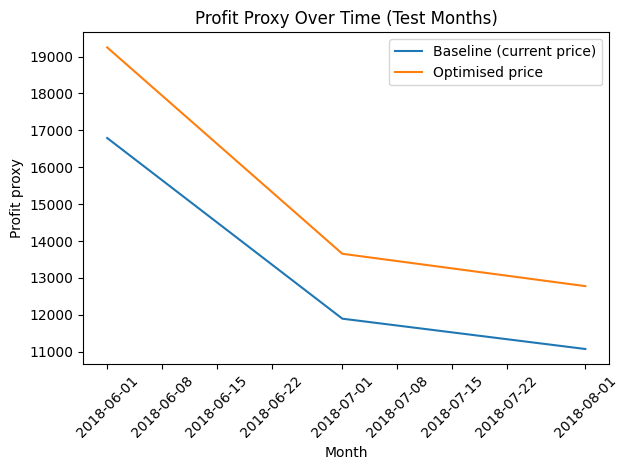

In [ ]:
# Create figures directory if it doesn't exist
import os
if not os.path.exists('figures'):
    os.makedirs('figures')

# 1) Profit proxy over time
profit_ts = (opt_results.groupby("month_year", as_index=False)
             .agg(profit_current=("profit_current","sum"),
                  profit_optimised=("profit_optimised","sum"))
             .sort_values("month_year"))

plt.figure()
plt.plot(profit_ts["month_year"], profit_ts["profit_current"], label="Baseline (current price)")
plt.plot(profit_ts["month_year"], profit_ts["profit_optimised"], label="Optimised price")
plt.title("Profit Proxy Over Time (Test Months)")
plt.xlabel("Month")
plt.ylabel("Profit proxy")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Figure 1: Profit proxy over time (baseline vs optimised)
This plot compares total profit proxy under current (historical) pricing versus optimised pricing across the holdout test months.

When the optimised line is consistently above baseline, it indicates the pricing policy improves expected profitability in a stable way, not just in one-off months.

If gaps widen in specific months, that suggests pricing opportunities are seasonality-driven (e.g., holiday demand, weekday/weekend mix), which could justify time-sensitive price rules.

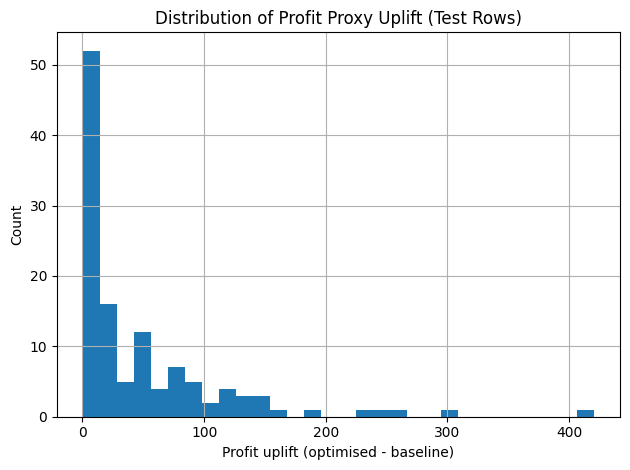

In [ ]:
# 2) Distribution of profit uplift
plt.figure()
opt_results["profit_uplift"].hist(bins=30)
plt.title("Distribution of Profit Proxy Uplift (Test Rows)")
plt.xlabel("Profit uplift (optimised - baseline)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Figure 2: This histogram shows how consistent the uplift is across product-month decisions.

* If most values are above zero, optimisation is broadly beneficial and low-risk to roll out.

* If the distribution is wide (large positive and negative tails), it suggests the demand model is uncertain for some products, and rollout should be staged (e.g., pilot categories first, add guardrails).

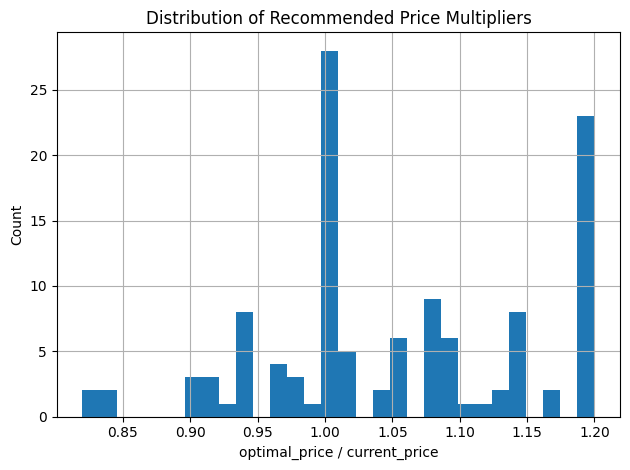

Recommended price multiplier summary:
count    120.000000
mean       1.053035
std        0.100479
min        0.820000
25%        1.000000
50%        1.030000
75%        1.140007
max        1.200000
dtype: float64

Pct > +15%: 0.20833333333333334
Pct < -15%: 0.03333333333333333


In [ ]:
# 3) Sanity check: recommended price change distribution
plt.figure()
ratio = opt_results["optimal_price"] / opt_results["current_price"]
ratio.hist(bins=30)
plt.title("Distribution of Recommended Price Multipliers")
plt.xlabel("optimal_price / current_price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Recommended price multiplier summary:")
print(ratio.describe())
print("\nPct > +15%:", (ratio > 1.15).mean())
print("Pct < -15%:", (ratio < 0.85).mean())

Figure 3: The histogram plot shows how much the recommended prices would change compared to the current prices.

The model usually suggests increasing prices, rather than cutting them.For many products (about 20.83%), the model recommends price increases of more than 15%. Only a small number of products (about 3.33%) are recommended for price cuts of more than 15%.
The model often tries to raise prices as much as it's allowed (up to 20% more as max value 1.20 aligns with PRICE_MAX_FACTOR), meaning it sees a lot of opportunity for higher prices within the set boundaries.

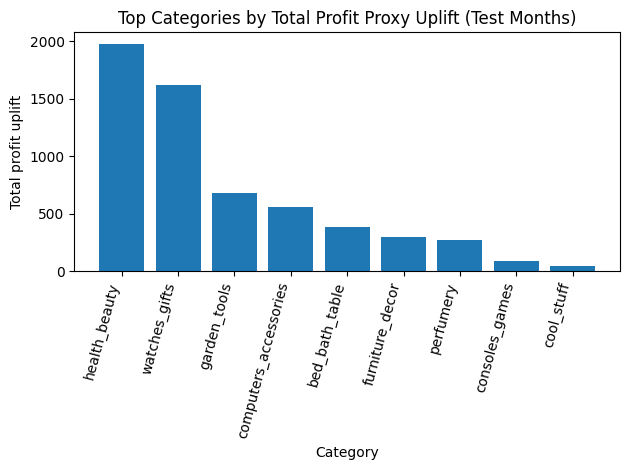

,product_category_name,profit_uplift
6,health_beauty,1977.561433
8,watches_gifts,1618.592589
5,garden_tools,682.725034
1,computers_accessories,556.063184
0,bed_bath_table,386.973411


In [ ]:
# 4) Uplift by category
uplift_by_category = opt_results.groupby("product_category_name")["profit_uplift"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="profit_uplift", y="product_category_name", data=uplift_by_category, palette="viridis", hue="product_category_name", legend=False)
plt.title("Total Profit Uplift by Product Category (Test Months)")
plt.xlabel("Profit Uplift")
plt.ylabel("Product Category")
plt.tight_layout()
plt.savefig('figures/profit_uplift_by_category.png')
plt.show()

Figure 4: The bar chart highlights the categories where the new pricing recommendations have the biggest positive impact on profit.
We can quickly see which product groups (like 'health_beauty' or 'watches_gifts' from the output) are the most promising to focus on when implementing the new pricing.

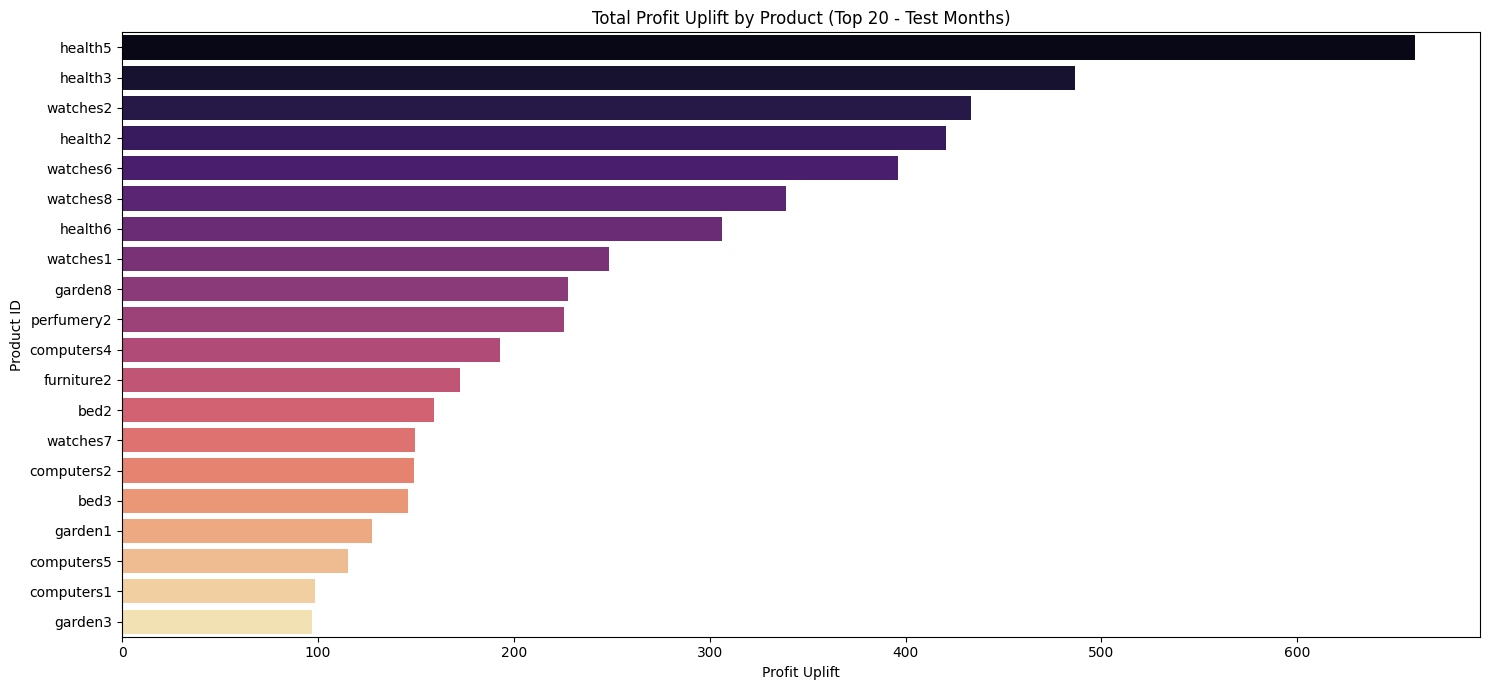

In [ ]:
uplift_by_product = opt_results.groupby("product_id")["profit_uplift"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(x="profit_uplift", y="product_id", data=uplift_by_product.head(20), palette="magma", hue="product_id", legend=False) # Showing top 20 products for clarity
plt.title("Total Profit Uplift by Product (Top 20 - Test Months)")
plt.xlabel("Profit Uplift")
plt.ylabel("Product ID")
plt.tight_layout()
plt.savefig('figures/profit_uplift_by_product.png')
plt.show()

Figure 5: The bar chart represents which individual products are expected to generate the most significant increase in profit when their prices are optimized. It helps to pinpoint specific 'star' products that will benefit most from the new pricing strategy, allowing for highly targeted price adjustments and enabling businesses to prioritize their efforts on the products that offer the largest potential profit gains.

**Conclusion**

We built a demand-based pricing system that predicts monthly unit demand (qty) from price and market context, then performs a grid-search optimisation to recommend prices that maximise a profit proxy.

Profit is estimated using a constant 25% margin proxy because unit cost data is unavailable; therefore, uplift reflects directional pricing value, not accounting profit.

Overall Profit Uplift:

The optimized pricing strategy demonstrated a significant increase in predicted profit proxy. Specifically, the analysis showed an uplift of 10900.84, translating to a 27.56% increase in profit proxy over the baseline during the test period.

The 'Profit Proxy Over Time' chart indicated that the optimized pricing consistently yielded higher profits than the baseline across the test months, suggesting a stable and beneficial pricing policy.

The 'Distribution of Profit Uplift' revealed that optimization was broadly beneficial across many product-month decisions. While most uplifts were positive, some variation suggests areas where the demand model might have more uncertainty.

The 'Profit Uplift by Product Category' chart identified specific categories, such as 'health_beauty' and 'watches_gifts', as having the highest total profit uplift, indicating where to prioritize pricing efforts.




Demand prediction quality:

* Validation MAE: 9.09

* Test MAE: 6.89

* Naive MAE (last month demand): 6.94

* Error is stable and moderate for retail demand.

* Lower test MAE indicates no overfitting and good generalisation to unseen months so the model is reliable enough for optimisation decisions.

The total profit proxy (baseline) was \$39,558.57.
*   The total profit proxy (optimized) increased to \$50,459.41.
*   This represents an uplift of \$10,900.84.
*   The uplift in percentage terms is approximately 27.56%.

**Business impact (using profit proxy)**

**Operational value**

* Identifies which products should change price and by how much.

* Quantifies expected profit uplift before rollout.

* Enables scalable, repeatable pricing decisions instead of manual judgement.

**Strategic value**

* Supports dynamic pricing capability.

* Reveals seasonal pricing opportunities.

* Provides foundation for automated pricing systems.

**Improvements:**

* Add real cost (replace profit proxy):
profit = (price − cost) × demand

* Constraints / guardrails:

  - max price change per month

  - competitor bounds (don’t price far above comp_1/2/3)

  - minimum margin and floor/ceiling prices

* Elasticity sanity check:

  - ensure demand generally decreases as price increases

  - flag products with unrealistic demand curves

* Uncertainty / safety rollout

  - optimise only when model confidence is high

   - pilot a few categories first

* Causal validation

  - A/B price tests to confirm uplift

**Key terms:**

**Uplift:** Extra gain or improvement. Additional profit you get by using the new, optimized prices compared to profit made with the old prices.

**Margin Rate:** Percentage of a product's selling price that is pure profit before considering other costs like marketing or operations.
e.g. If a product sells for \$100 and has a 25% margin, \$25 of $100 is available as profit to cover other business expenses and eventually contribute to net profit.

**Profit Proxy:** This is a substitute for the true profit. Because the full cost of each product (how much it costs to make or buy) isn't available in this dataset, we estimate profit using only the selling price and an assumed margin rate.

**Rolling mean (moving average):** is a way to smooth out data over time and highlight longer-term trends or patterns.
e.g. '3-month rolling mean', for each month, you take the average of that month's sales and the sales from the previous two months. Then 'roll' that window forward to the next month and do it again.